<h2>Pricing e-commerce : estimation de l'élasticité et optimisation du prix</h2>

Le pricing consiste à déterminer le prix optimal d’un produit, c’est-à-dire celui qui permet de maximiser le profit. Cet exercice est délicat : un prix trop élevé peut entraîner une baisse de la demande, tandis qu’un prix trop bas réduit la marge réalisée sur chaque vente.

In [1]:
import pandas as pd

df = pd.read_excel("online_retail_II.xlsx", nrows=100000) #le fichier xlsx est très lourd, je prends une partie

#Le format CSV est plus léger et plus rapide à charger pour les traitements ultérieurs.
df.to_csv("data.csv", index=False)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      100000 non-null  object        
 1   StockCode    100000 non-null  object        
 2   Description  99130 non-null   object        
 3   Quantity     100000 non-null  int64         
 4   InvoiceDate  100000 non-null  datetime64[ns]
 5   Price        100000 non-null  float64       
 6   Customer ID  72861 non-null   float64       
 7   Country      100000 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 6.1+ MB


## Description du dataset *Online Retail*

Ce dataset contient des transactions d’un site e-commerce. Chaque ligne correspond à un produit acheté dans une commande.

---

### `Invoice`

* Numéro de facture (transaction)
* Plusieurs lignes peuvent partager le même `Invoice` : elles appartiennent à une même commande
* Les valeurs commençant par "C" indiquent une annulation ou un retour

---

### `StockCode`

* Identifiant unique du produit
* Permet d’analyser les ventes produit par produit

---

### `Description`

* Nom ou description du produit
* Utile pour l’interprétation, mais non essentiel pour la modélisation

---

### `Quantity`

* Quantité achetée du produit
* Peut être négative en cas de retour

---

### `InvoiceDate`

* Date et heure de la transaction
* Permet d’analyser les évolutions temporelles (tendances, saisonnalité)

---

### `Price`

* Prix unitaire du produit
* Variable centrale pour l’analyse de la demande

---

### `Customer ID`

* Identifiant du client
* Peut être manquant
* Permet des analyses comportementales

---

### `Country`

* Pays du client
* Utile pour segmenter la demande selon les marchés

---

## Objectif du projet

Utiliser ces données pour :

* estimer une fonction de demande (D(p))
* analyser l’élasticité au prix
* déterminer un prix optimal maximisant le profit (ou le revenu en première approximation)

---


<h2>Prétraitement des données</h2>

In [3]:
# Les quantités négatives correspondent aux retours (credit notes)
# Elles ne reflètent pas une demande réelle → on les inspecte avant suppression
df[df['Quantity'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
99827,498775,20944,NaN,-26,2010-02-23 10:19:00,0.00,NaN,United Kingdom
99835,C498777,84927A,WAKE UP COCKEREL TILE HOOK,-1,2010-02-23 10:48:00,2.10,12500.0,Germany
99836,C498777,22243,"HOOK, 5 HANGER ,MAGIC TOADSTOOL RED",-3,2010-02-23 10:48:00,1.65,12500.0,Germany
99949,C498781,22202,MILK PAN PINK RETROSPOT,-8,2010-02-23 10:50:00,3.75,12647.0,Germany


In [4]:
# On conserve uniquement les transactions correspondant à une demande effective (quantités strictement positives)
df = df[df['Quantity'] > 0]

In [5]:
# On conserve uniquement les observations avec un prix strictement positif,
# car un prix nul ou négatif ne correspond pas à une transaction économique valide
df = df[df['Price'] > 0]

On va filtrer sur un seul pays afin d’homogénéiser les données. En effet, le comportement de la demande peut varier selon les marchés (pouvoir d’achat, concurrence, habitudes de consommation), ce qui rendrait l’estimation d’une relation unique entre prix et demande moins pertinente.

In [6]:
df['Country'].value_counts()

Country
United Kingdom          90708
EIRE                     1536
Germany                  1330
France                    964
Spain                     382
Netherlands               372
Cyprus                    244
Belgium                   175
United Arab Emirates      167
Greece                    142
Portugal                  127
USA                       106
Austria                    94
Denmark                    79
Channel Islands            66
RSA                        65
Unspecified                64
Australia                  46
Malta                      46
Sweden                     41
Finland                    37
Switzerland                35
Japan                      30
Bahrain                    29
Poland                     22
Norway                     21
Italy                      20
Nigeria                     1
Name: count, dtype: int64

In [7]:
# On restreint l'analyse au Royaume-Uni, pays le plus représenté dans le dataset
df = df[df['Country'] == 'United Kingdom']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90708 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      90708 non-null  object        
 1   StockCode    90708 non-null  object        
 2   Description  90708 non-null  object        
 3   Quantity     90708 non-null  int64         
 4   InvoiceDate  90708 non-null  datetime64[ns]
 5   Price        90708 non-null  float64       
 6   Customer ID  64749 non-null  float64       
 7   Country      90708 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 6.2+ MB


Après prétraitement, le dataset ne contient plus que des transactions valides (quantités et prix strictement positifs) et est restreint à un seul marché. Cela permet de travailler sur un ensemble de données plus homogène pour l’estimation de la demande.

<h2>Sélection d’un produit pour l’estimation de la demande et du pricing</h2>

In [9]:
# On compte le nombre de produits différents de notre dataset
df['StockCode'].nunique()

3397

In [10]:
# On classe les produits par nombre d'occurrences (transactions) dans le dataset
df.groupby('StockCode')['Quantity'].count().sort_values(ascending=False)

StockCode
85123A      728
21232       348
21212       335
22111       334
85099B      321
           ... 
DCGS0044      1
DCGS0004      1
90050         1
90041         1
90032         1
Name: Quantity, Length: 3397, dtype: int64

<b>Nous cherchons un produit avec un nombre élevé d’observations et une variabilité suffisante des prix, afin de pouvoir estimer de manière fiable la relation entre prix et demande.</b>

In [11]:
# L'analyse exploratoire montre qu'à partir de 10 unités, des remises sont appliquées,
# ce qui modifie la relation entre prix et demande.
# On restreint donc l'analyse aux petites quantités pour se concentrer sur un comportement homogène.
df = df[df['Quantity'] < 10]

In [12]:
# Pour chaque produit, on calcule :
# - le nombre d'observations (robustesse statistique)
# - le nombre de prix distincts (variabilité nécessaire à l'estimation)
product_stats = df.groupby('StockCode').agg({
    'Quantity': 'count',
    'Price': 'nunique'
}).rename(columns={'Quantity': 'count', 'Price': 'n_prices'})

In [13]:
# On retient les produits avec suffisamment d'observations et une variabilité de prix suffisante
# pour permettre une estimation robuste de la demande
product_stats[(product_stats['count'] > 100) & (product_stats['n_prices'] > 4)]

,count,n_prices
StockCode,,
21523,159,5
21955,155,5
48138,137,5
79323P,149,5
84032A,110,5
85123A,411,5
DOT,140,135


In [14]:
produit = df[df['StockCode'] == 21523]
produit

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
868,489537,21523,FANCY FONT HOME SWEET HOME DOORMAT,1,2009-12-01 12:14:00,6.75,14040.0,United Kingdom
3574,489728,21523,FANCY FONT HOME SWEET HOME DOORMAT,2,2009-12-02 11:18:00,6.75,14799.0,United Kingdom
3972,489791,21523,FANCY FONT HOME SWEET HOME DOORMAT,1,2009-12-02 12:06:00,6.75,15542.0,United Kingdom
4359,489810,21523,FANCY FONT HOME SWEET HOME DOORMAT,2,2009-12-02 12:47:00,6.75,18108.0,United Kingdom
6033,489866,21523,FANCY FONT HOME SWEET HOME DOORMAT,4,2009-12-02 15:04:00,6.75,16200.0,United Kingdom
...,...,...,...,...,...,...,...,...
97449,498549,21523,DOOR MAT FANCY FONT HOME SWEET HOME,2,2010-02-19 18:04:00,13.57,NaN,United Kingdom
98158,498584,21523,DOOR MAT FANCY FONT HOME SWEET HOME,2,2010-02-21 15:06:00,7.49,16200.0,United Kingdom
98268,498589,21523,DOOR MAT FANCY FONT HOME SWEET HOME,6,2010-02-21 15:19:00,7.49,14895.0,United Kingdom
98498,498601,21523,DOOR MAT FANCY FONT HOME SWEET HOME,4,2010-02-21 16:09:00,7.49,13538.0,United Kingdom


In [15]:
produit['Price'].unique()

array([ 6.75, 13.87,  5.95, 13.57,  7.49])

In [16]:
agg = produit.groupby('Price')['Quantity'].sum().reset_index()
agg

,Price,Quantity
0,5.95,160
1,6.75,140
2,7.49,35
3,13.57,26
4,13.87,22


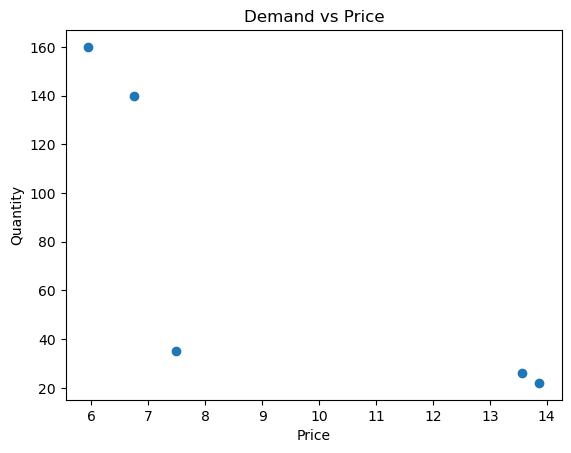

In [17]:
import matplotlib.pyplot as plt

plt.scatter(agg['Price'], agg['Quantity'])
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title("Demand vs Price")
plt.show()

<h3>Modèle :</h3>

On cherche dans un premier temps à estimer l’élasticité prix de la demande du produit.

On suppose que la demande suit un modèle de type :
D(p) = A p^{-e}

En prenant le logarithme, on obtient une relation linéaire :
log(D) = log(A) - e log(p)

En posant Y = log(D) et X = log(p), on peut estimer ce modèle par régression linéaire.

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression


agg['log_p'] = np.log(agg['Price'])
agg['log_q'] = np.log(agg['Quantity']) # log_q correspond à log(D), où D est la demande agrégée

model = LinearRegression().fit(agg[['log_p']], agg['log_q'])

epsilon = -model.coef_[0]
A = np.exp(model.intercept_)

print("Elasticité :", epsilon)

Elasticité : 2.072247954083403


## Interprétation de l’élasticité prix de la demande

L’élasticité estimée est égale à 2.07.

Cela signifie qu’une augmentation de 1 % du prix entraîne en moyenne une diminution d’environ 2.07 % de la quantité demandée. La demande est donc dite **élastique**, car l’élasticité est supérieure à 1 en valeur absolue.

Ce résultat indique une forte sensibilité des consommateurs au prix. De petites variations de prix peuvent engendrer des variations importantes de la demande.

D’un point de vue économique, lorsque la demande est élastique, une augmentation du prix tend à réduire le chiffre d’affaires, tandis qu’une baisse du prix peut permettre d’augmenter les ventes et potentiellement le revenu.

Il convient toutefois de rester prudent dans l’interprétation de ce résultat. L’estimation repose sur un nombre limité d’observations et sur un modèle supposant une élasticité constante. Ces hypothèses constituent une approximation du comportement réel des consommateurs.

<h3>Exploitation économique</h3>

In [19]:
agg['Revenue'] = agg['Price'] * agg['Quantity']
agg

,Price,Quantity,log_p,log_q,Revenue
0,5.95,160,1.783391,5.075174,952.00
1,6.75,140,1.909543,4.941642,945.00
2,7.49,35,2.013569,3.555348,262.15
3,13.57,26,2.607861,3.258097,352.82
4,13.87,22,2.629728,3.091042,305.14


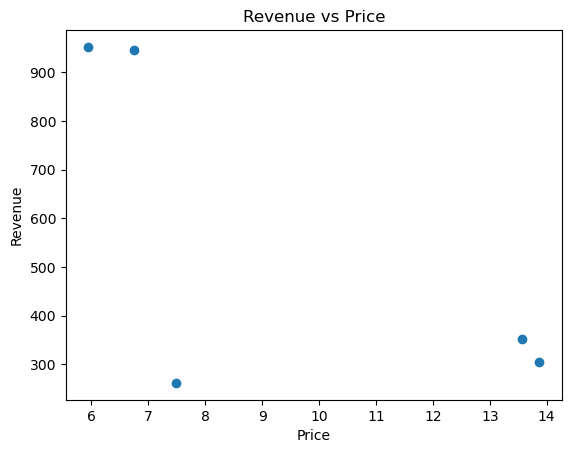

In [20]:
import matplotlib.pyplot as plt

plt.scatter(agg['Price'], agg['Revenue'])
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Revenue vs Price")
plt.show()

## Analyse du revenu

Le revenu est maximal pour les niveaux de prix les plus faibles. Une augmentation du prix au-delà de 6.75 entraîne une chute importante du revenu, ce qui est cohérent avec une élasticité supérieure à 1.

On observe également que les prix 5.95 et 6.75 génèrent des revenus très proches, suggérant l’existence d’une zone de prix optimale plutôt qu’un point unique.

Ces résultats confirment qu’une stratégie de prix bas, associée à un volume de vente élevé, est préférable pour ce produit.

## Conclusion

Dans ce projet, nous avons cherché à estimer la relation entre le prix et la demande pour un produit donné à partir de données transactionnelles issues d’un site e-commerce.

Après un travail de prétraitement visant à nettoyer et homogénéiser les données (suppression des retours, filtrage des prix non valides, restriction à un seul pays), nous avons sélectionné un produit présentant à la fois un nombre suffisant d’observations et une variabilité de prix exploitable.

Nous avons ensuite estimé une fonction de demande de type puissance, supposant une élasticité constante, en utilisant une transformation logarithmique permettant une estimation par régression linéaire.

L’élasticité estimée est d’environ 2.07, ce qui indique une demande fortement élastique. Les consommateurs apparaissent donc très sensibles aux variations de prix.

L’analyse du revenu montre que les niveaux de prix les plus faibles génèrent le chiffre d’affaires le plus élevé. Une augmentation du prix au-delà d’un certain seuil entraîne une diminution importante des ventes et du revenu. On observe également une zone de prix optimale, plutôt qu’un point unique, suggérant une certaine flexibilité dans la stratégie de pricing.

Ces résultats sont cohérents avec la théorie économique et permettent de formuler des recommandations opérationnelles en matière de fixation des prix.

## Limites du modèle

Malgré des résultats cohérents, plusieurs limites importantes doivent être soulignées.

Tout d’abord, l’analyse repose sur un nombre très limité d’observations agrégées (cinq niveaux de prix), ce qui rend l’estimation de l’élasticité sensible au bruit et aux points atypiques.

Ensuite, le modèle suppose une élasticité constante, ce qui constitue une approximation simplificatrice du comportement réel des consommateurs. En pratique, la sensibilité au prix peut varier selon le niveau de prix ou le contexte.

Par ailleurs, les données utilisées sont observationnelles. Le prix n’est pas une variable exogène et peut être influencé par la demande, les promotions ou d’autres facteurs non observés. Cela peut introduire un biais dans l’estimation de la relation prix-demande.

Le modèle ne prend également pas en compte d’autres variables explicatives importantes, telles que la saisonnalité, le marketing, la concurrence ou les caractéristiques des clients.

Enfin, le filtrage des données (notamment l’exclusion des achats en grande quantité) modifie la structure de l’échantillon et peut introduire un biais, même s’il permet de réduire l’hétérogénéité.

Ces limites doivent être gardées à l’esprit dans l’interprétation des résultats.